# Importing of Libraries

* Library **pandas**: to handle data in tabular representation.
* Library **numpy**: for linear algebra routines.
* Library **missingno**: to graphically display missing values in the data.
* Library **re**: to work with regular expressions.
* Library **matplotlib, seaborn**: to visualize data in in plots, graphs and charts.

In [11]:
import pandas as pd
import numpy as np
import missingno as msno
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns

| Import                | Purpose                                 | Example                                        |
| --------------------- | --------------------------------------- | ---------------------------------------------- |
| `make_subplots`       | Combine multiple charts into one figure | 2×2 dashboard                                  |
| `graph_objects (go)`  | Create interactive charts               | Bar, Pie, Scatter, Box, Histogram              |
| `figure_factory (ff)` | Create specialized charts               | Tables, Distribution plots, Annotated heatmaps |


In [12]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.figure_factory as ff

# Data Cleaning

In [13]:
df = pd.read_csv("/content/Amazon Sale Report.csv",low_memory=False)
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [14]:
df_sizes = {'start': df.shape}

In [15]:
print(f"Raw data contains {df_sizes['start'][0]} records and {df_sizes['start'][1]} columns.")

Raw data contains 128975 records and 24 columns.


In [16]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [17]:
df = df.rename(columns={'Order ID': 'Order_ID', 'Sales Channel ': 'Sales_channel',
        'ship-service-level': 'ship_service_level', 'ship-city': 'ship_city',
        'ship-state': 'ship_state', 'ship-postal-code': 'ship_postal_code', 'ship-country': 'ship_country',
        'promotion-ids': 'promotion_ids','Courier Status': 'Courier_Status', 'currency': 'Currency',
        'fulfilled-by':'fulfilled_by'})

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order_ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales_channel       128975 non-null  object 
 6   ship_service_level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier_Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  Currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [19]:
df.set_index('index', inplace = True)

In [20]:
def missing_evaluation(dataframe):
    '''
    missing_evaluation(dataframe)

    Returns a dataframe containing the informations about missing and unique values
    for each column on a dataframe passed as a parameter

    Parameters:
    dataframe: dataframe to analyze
    '''

    # Column 'qt_missing': Number of NaN values
    df_missing_stats = pd.DataFrame(data=dataframe.isna().sum(), index=dataframe.columns, columns=['qt_missing'])
    # Column 'nr_unique_values': Number of unique values
    df_missing_stats['qt_unique_values'] = pd.DataFrame(data=dataframe.nunique(), index=dataframe.columns)
    # Column 'unique_values': unique values of the attributes
    df_missing_stats['unique_values'] = pd.DataFrame(data=dataframe.apply(pd.unique), index=dataframe.columns)
    # Column 'perc_missing': percentage of missing values
    df_missing_stats['perc_missing'] = pd.DataFrame(data=dataframe.isnull().mean())
    return df_missing_stats

In [21]:
df_missing_stats = missing_evaluation(df)
df_missing_stats

,qt_missing,qt_unique_values,unique_values,perc_missing
Order_ID,0,120378,"[405-8078784-5731545, 171-9198151-1101146, 404...",0.000000
Date,0,91,"[04-30-22, 04-29-22, 04-28-22, 04-27-22, 04-26...",0.000000
Status,0,13,"[Cancelled, Shipped - Delivered to Buyer, Ship...",0.000000
Fulfilment,0,2,"[Merchant, Amazon]",0.000000
Sales_channel,0,2,"[Amazon.in, Non-Amazon]",0.000000
ship_service_level,0,2,"[Standard, Expedited]",0.000000
Style,0,1377,"[SET389, JNE3781, JNE3371, J0341, JNE3671, SET...",0.000000
SKU,0,7195,"[SET389-KR-NP-S, JNE3781-KR-XXXL, JNE3371-KR-X...",0.000000
Category,0,9,"[Set, kurta, Western Dress, Top, Ethnic Dress,...",0.000000
Size,0,11,"[S, 3XL, XL, L, XXL, XS, 6XL, M, 4XL, 5XL, Free]",0.000000


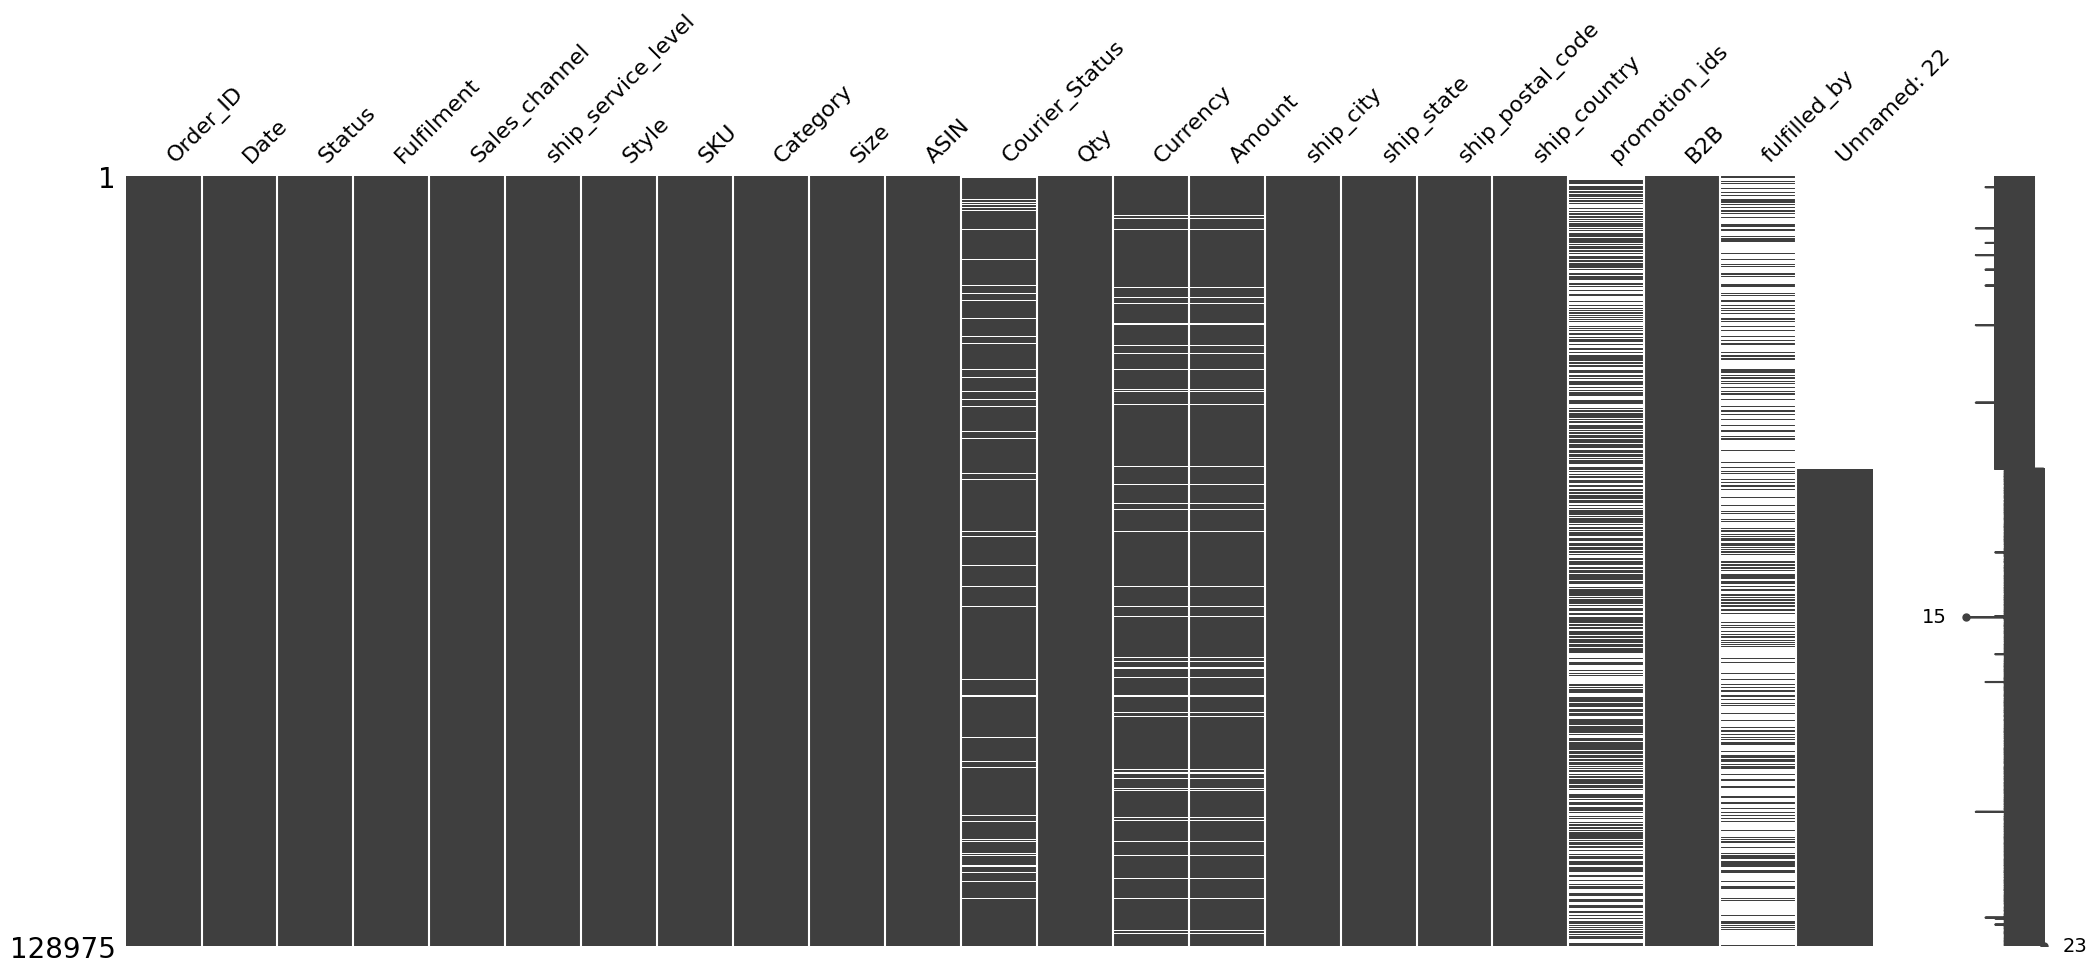

In [22]:
# Visualize the distribution of missing values with missingno matrix
msno.matrix(df);

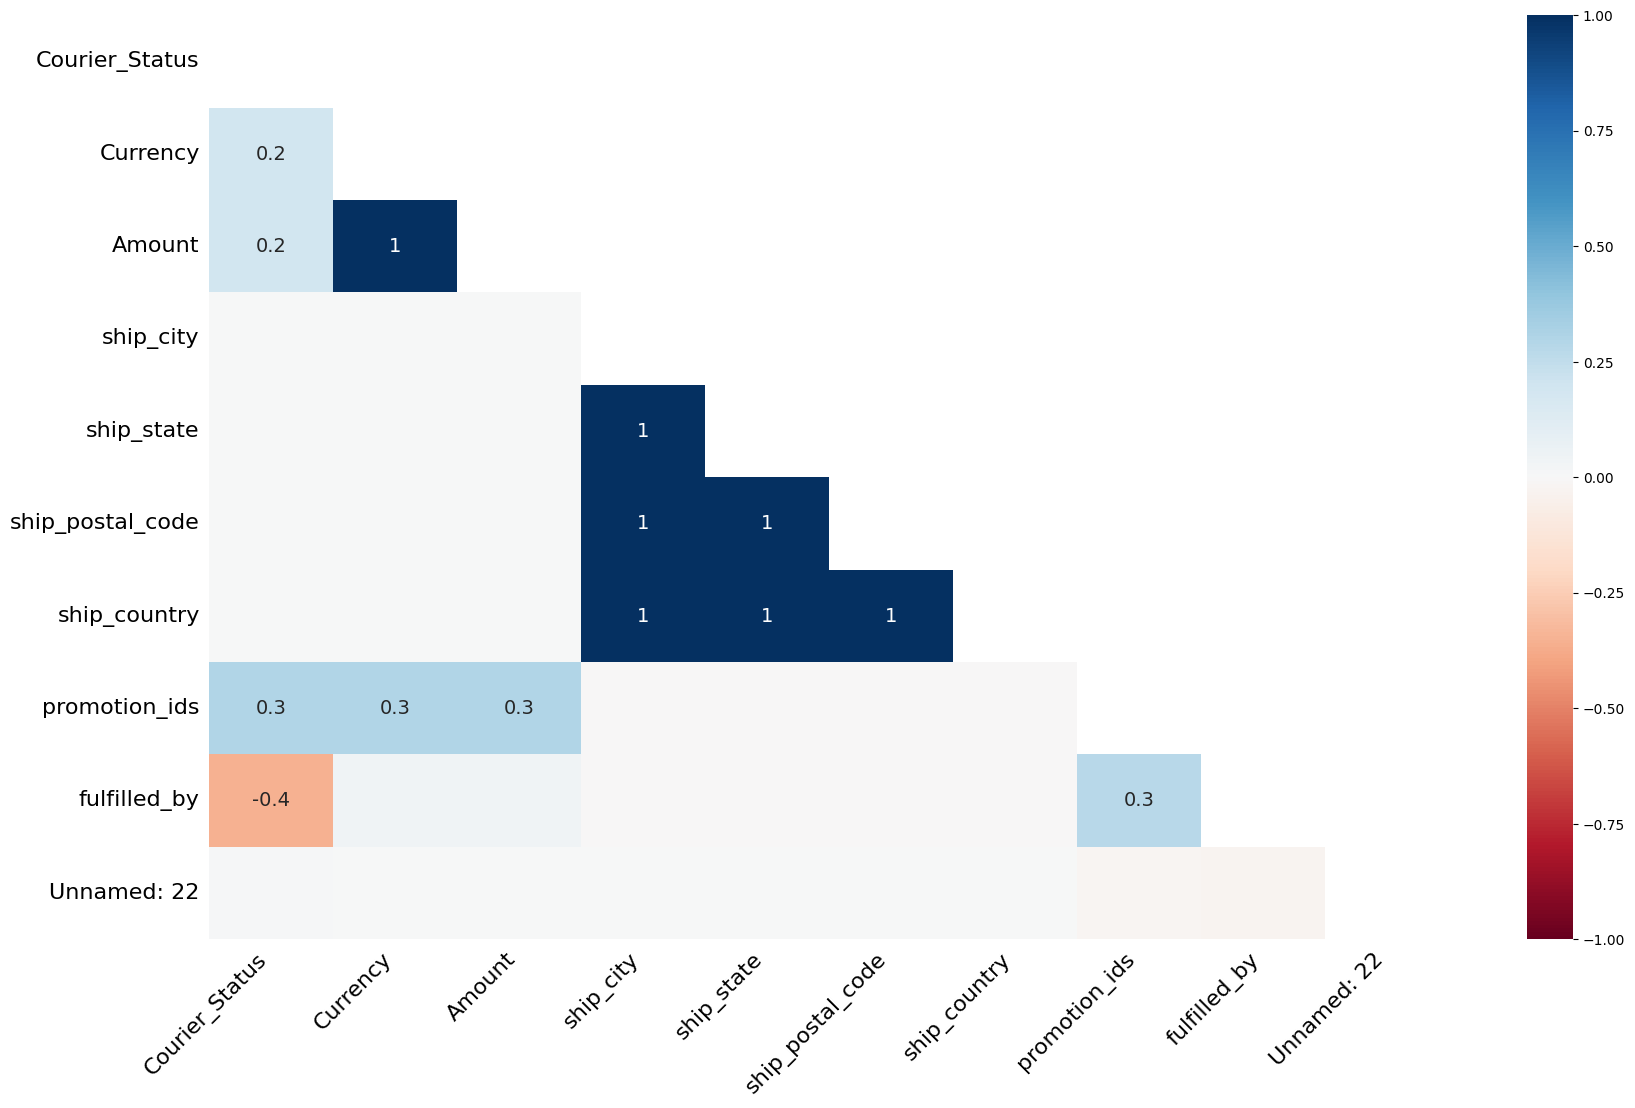

In [23]:
# Use the heatmap to identify correlations of the nullity between each of the different columns.
msno.heatmap(df);

* When one of the columns **'Amount'** and **'Currency'** is null, the other is also null (7795 raws with null values).
* When one of columns **'ship_city', 'ship_state', 'ship_postal_code', 'ship_country'** has a null value, the others are also null (33 raws with null values).

### Fill in (or eliminate) the missing values with a case-by-case assessment.
After the exploration of the missing values, it's possible to proceed fill (or clean) each column, performing an individual assessment.

* **Courier_Status**: missing values filled with 'Unknown'

In [24]:
# Replace NaN values in column 'Courier_Status' with the value 'Unknown'
df['Courier_Status'].fillna('Unknown', inplace = True)

/tmp/ipykernel_4633/879528417.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Courier_Status'].fillna('Unknown', inplace = True)


* Check nullity correlation on **Amount** and **Currency** columns
* Fill missing values in **Amount** with zero
* Fill missing values in **Currency** with 'INR'

In [25]:
set_idx_amount_null = set(df[df['Amount'].isnull()].index)

In [26]:
set2_idx_currency_null = set(df[df['Currency'].isnull()].index)

In [27]:
print(f"Question: Columns 'Amount' and 'Currency' have 1 to 1 nullity correlation?\nAnswer: {set_idx_amount_null == set2_idx_currency_null}")

Question: Columns 'Amount' and 'Currency' have 1 to 1 nullity correlation?
Answer: True


In [28]:
df['Amount'].fillna(0, inplace = True)

/tmp/ipykernel_4633/4267837074.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Amount'].fillna(0, inplace = True)


In [29]:
df['Currency'].fillna('INR', inplace = True)

/tmp/ipykernel_4633/2678195068.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Currency'].fillna('INR', inplace = True)


In [30]:
# Replace NaN values in column 'promotion_ids' with the value 'Unknown'
df['promotion_ids'].fillna('No Promo', inplace = True)

/tmp/ipykernel_4633/2107257680.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['promotion_ids'].fillna('No Promo', inplace = True)


* **ship_city** and **ship_state**: missing values filled with 'Unknown'
* **ship_postal_code**: missing values filled with zero
* **ship_country**: missing values filled with 'Unknown'

In [31]:
df['ship_city'].fillna('Unknown', inplace = True)
df['ship_state'].fillna('Unknown', inplace = True)
df['ship_postal_code'].fillna(0, inplace = True)
df['ship_country'].fillna('Unknown', inplace = True)

/tmp/ipykernel_4633/3931634243.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ship_city'].fillna('Unknown', inplace = True)
/tmp/ipykernel_4633/3931634243.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

* **fulfilled_by**: missing values filled with 'FBA' (Fulfilled by Amazon).

In [32]:
df['fulfilled_by'].fillna('FBA', inplace = True)

/tmp/ipykernel_4633/646876717.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['fulfilled_by'].fillna('FBA', inplace = True)


In [33]:
df.drop(columns = ['Unnamed: 22'], inplace = True)

In [34]:
df.isna().sum().sum()

np.int64(0)

In [35]:
df_missing_stats = missing_evaluation(df)
df_missing_stats

,qt_missing,qt_unique_values,unique_values,perc_missing
Order_ID,0,120378,"[405-8078784-5731545, 171-9198151-1101146, 404...",0.0
Date,0,91,"[04-30-22, 04-29-22, 04-28-22, 04-27-22, 04-26...",0.0
Status,0,13,"[Cancelled, Shipped - Delivered to Buyer, Ship...",0.0
Fulfilment,0,2,"[Merchant, Amazon]",0.0
Sales_channel,0,2,"[Amazon.in, Non-Amazon]",0.0
ship_service_level,0,2,"[Standard, Expedited]",0.0
Style,0,1377,"[SET389, JNE3781, JNE3371, J0341, JNE3671, SET...",0.0
SKU,0,7195,"[SET389-KR-NP-S, JNE3781-KR-XXXL, JNE3371-KR-X...",0.0
Category,0,9,"[Set, kurta, Western Dress, Top, Ethnic Dress,...",0.0
Size,0,11,"[S, 3XL, XL, L, XXL, XS, 6XL, M, 4XL, 5XL, Free]",0.0


# 2.3 Uniform the values in each column
To make values consistent, such as eliminating duplicates and having unique values, it is first of all necessary to standardize the style of the strings.
It's a procedure in which the intervention to apply for each column must be evaluated individually.

* **Order_ID**: it's proper that it's a string, remove extra white spaces from the beginning and end, and set the characters in UPPER case.

In [36]:
df['Order_ID'] = df['Order_ID'].str.strip()

In [37]:
df['Order_ID'] = df['Order_ID'].str.upper()

* **Date**: it's in string format, set it to to dtype datetime.

In [38]:
# Set column 'Date' to data type datetime
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_4633/2574689105.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


* **Status**: it's proper that it's a string, remove extra white spaces from the beginning and end.   
Then check if there are the same 'Status' values but with different spellings.  
As verified above, it contains 13 values, so they can be checked visually one by one, avoiding apply without distinction Capitalize or UPPER methods, keeping the contents legible at a glance within possible limits.

In [39]:
df['Status'] = df['Status'].str.strip()

In [40]:
# Check column 'Status', result: it doesn't need intervention
for value in df.Status.sort_values().unique():
    print(f"'{value}'")

'Cancelled'
'Pending'
'Pending - Waiting for Pick Up'
'Shipped'
'Shipped - Damaged'
'Shipped - Delivered to Buyer'
'Shipped - Lost in Transit'
'Shipped - Out for Delivery'
'Shipped - Picked Up'
'Shipped - Rejected by Buyer'
'Shipped - Returned to Seller'
'Shipped - Returning to Seller'
'Shipping'


* **Fulfilment**: contains 2 unique values ('Merchant' and 'Amazon'), and are already written in the correct form
* **Sales_channel**: contains 2 unique values ('Amazon.in' and 'Non-Amazon'), and are already written in the correct form
* **ship_service_level**: contains 2 unique values('Standard' and 'Expedited'), and are already written in the correct form

* **Style** and **SKU**: it's proper that they are strings, remove extra white spaces from the beginning and end, and set the characters in UPPER case.

In [41]:
df['Style'] = df['Style'].str.strip()
df['Style'] = df['Style'].str.upper()
df['SKU'] = df['SKU'].str.strip()
df['SKU'] = df['SKU'].str.upper()

* **Category**: it's proper that it's a string, remove extra white spaces from the beginning and end, and set the characters in UPPER case.

In [42]:
df['Category'] = df['Category'].str.strip()
df['Category'] = df['Category'].str.upper()

* **Size**: contains 11 unique values, and as can be seen from the table above they are already written in the correct form.

* **ASIN**: it's proper that it's a string, remove extra white spaces from the beginning and end, and set the characters in UPPER case.

In [43]:
df['ASIN'] = df['ASIN'].str.strip()
df['ASIN'] = df['ASIN'].str.upper()

* **Courier_Status**: contains 4 unique values (Shipped, Cancelled, Unshipped, Unknown), and are already written in the correct form.   
* **Qty**: is a integer number, with max value of 15 units. It doesn't nedd intervention.
* **Currency**: contains 1 unique value (INR), and is already written in the correct form.  
* **Amount**: is a float number. With the measurements made so far it doesn't seem to need intervention.

* **ship_city** and **ship_state**: it’s proper that they are strings, remove extra white spaces from the beginning and end, and uniform all the characters to UPPER case. Then check the accuracy of geographic names. And normalize different istances of the same state and city.

In [44]:
df['ship_city'] = df['ship_city'].str.strip()
df['ship_city'] = df['ship_city'].str.upper()
df['ship_state'] = df['ship_state'].str.strip()
df['ship_state'] = df['ship_state'].str.upper()

In [45]:
df.loc[df['ship_state'].isin(['AR']),'ship_state'] = 'ARUNACHAL PRADESH'
df.loc[df['ship_state'].isin(['NEW DELHI']),'ship_state'] = 'DELHI'
df.loc[df['ship_state'].isin(['NL']),'ship_state'] = 'NAGALAND'
df.loc[df['ship_state'].isin(['ORISSA']),'ship_state'] = 'ODISHA'
df.loc[df['ship_state'].isin(['PONDICHERRY']),'ship_state'] = 'PUDUCHERRY'
df.loc[df['ship_state'].isin(['PUNJAB/MOHALI/ZIRAKPUR','PB']),'ship_state'] = 'PUNJAB'
df.loc[df['ship_state'].isin(['RAJSHTHAN','RAJSTHAN','RJ']),'ship_state'] = 'RAJASTHAN'

In [46]:
df['ship_city'] = df['ship_city'].replace(['PUDUCHERRY','PONDYCHERRY', 'PUDUCHERRY 605001', 'PUDUCHERRY 605003'],'PUDUCHERRY')

In [47]:
df['ship_city'] = df['ship_city'].replace(['NORTH DELHI', 'NORTH WEST DELHI','NEW DELHI (NORTH)'],'NEW DELHI (NORTH)')
df['ship_city'] = df['ship_city'].replace(['SOUTH  DELHI', 'SOUTH DELHI'],'NEW DELHI (SOUTH)')
df['ship_city'] = df['ship_city'].replace(['SOUTH EAST DELHI'],'NEW DELHI (SOUTH EAST)')
df['ship_city'] = df['ship_city'].replace(['SOUTH WEST DELHI','SOUTH-WEST DELHI'],'NEW DELHI (SOUTH WEST)')
df['ship_city'] = df['ship_city'].replace(['WEST DELHI'],'NEW DELHI (WEST)')
df['ship_city'] = df['ship_city'].replace(['CENTRAL DELHI','CITY'],'NEW DELHI (CENTRAL)')
df['ship_city'] = df['ship_city'].replace(['EAST DELHI'],'NEW DELHI (EAST)')

In [48]:
pattern = r'^NEW DELHI(?!.*\()'
df['ship_city'] = df['ship_city'].apply(lambda x: "NEW DELHI" if re.match(pattern, x) else x)

In [49]:
df['ship_city'] = df['ship_city'].replace(['N.DELHI','NEW DELH','DELHI','DELHI -86','DELHI 110085','DELHI CANTT','DELHI-92.','DELHIQ', 'NEW-DELHI',
 'NEWDELHI'],'NEW DELHI')

In [50]:
pattern = r'^BANGALOR(?!.*\()'
df['ship_city'] = df['ship_city'].apply(lambda x: 'BANGALORE' if re.match(pattern, x) else x)
df['ship_city'] = df['ship_city'].apply(lambda x: 'BANGALORE' if re.match(r'^BENGALUR(?!.*\()', x) else x)
df['ship_city'] = df['ship_city'].replace(['BENGALOORU','BENGOLOOR', 'BANGALURU'],'BANGALORE')

Note: since this notebook is for demonstration purposes only, I normalized all State names, and only the cities of Puducherry, New Delhi and Bangalore.

* **ship_postal_code**: it's currently a float, but postal code is a categorical data, so it needs to be converted in string. Remember that all missing values have been replaced with zeros.

In [51]:
df['ship_postal_code'] = df['ship_postal_code'].astype(str)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128975 entries, 0 to 128974
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order_ID            128975 non-null  object        
 1   Date                128975 non-null  datetime64[ns]
 2   Status              128975 non-null  object        
 3   Fulfilment          128975 non-null  object        
 4   Sales_channel       128975 non-null  object        
 5   ship_service_level  128975 non-null  object        
 6   Style               128975 non-null  object        
 7   SKU                 128975 non-null  object        
 8   Category            128975 non-null  object        
 9   Size                128975 non-null  object        
 10  ASIN                128975 non-null  object        
 11  Courier_Status      128975 non-null  object        
 12  Qty                 128975 non-null  int64         
 13  Currency            128975 non-nul

* **promotion_ids**: it's proper that it is a string, remove extra white spaces from the beginning and end, and set the characters in UPPER case.

In [53]:
df['promotion_ids'] = df['promotion_ids'].str.strip()
df['promotion_ids'] = df['promotion_ids'].str.upper()

* **B2B**: boolean, True when the sale is Business to Business, False when is Business to Consumer. It doesn't needs intervention.
* **fulfilled_by**: contains 2 unique values (Easy Ship, FBA). It doesn't needs intervention.

# 2.4 Remove Duplicates

* Remove duplicate rows

In [54]:
df.drop_duplicates(inplace = True)

In [55]:
df_sizes.update({'after_remove_duplicates': df.shape})
print(f"Deleted {df_sizes['start'][0] - df_sizes['after_remove_duplicates'][0] } raws, {df_sizes['after_remove_duplicates'][0]} remain.")

Deleted 6 raws, 128969 remain.


* Remove **fulfilled_by** column, bacause it doesn't add information to data. In fact it contains the same information as the column **Fulfilment**.

In [56]:
print(f"""
Question: When the value in column 'Fulfilment' is 'Merchant', the value in column 'fulfilled_by' is 'Easy Ship'?
Answer:   {set(df.query("Fulfilment == 'Merchant'").index) == set(df.query("fulfilled_by == 'Easy Ship'").index)}""")
print(f"""
Question: When the value in column 'Fulfilment' is 'Amazon', the value in column 'fulfilled_by' is 'FBA'?
Answer:   {set(df.query("Fulfilment == 'Merchant'").index) == set(df.query("fulfilled_by == 'Easy Ship'").index)}""")


Question: When the value in column 'Fulfilment' is 'Merchant', the value in column 'fulfilled_by' is 'Easy Ship'?
Answer:   True

Question: When the value in column 'Fulfilment' is 'Amazon', the value in column 'fulfilled_by' is 'FBA'?
Answer:   True


In [57]:
df.drop(columns = ['fulfilled_by'], inplace = True)

# 2.5 Numeric data

In [58]:
df['Date'] = pd.to_datetime(df['Date'])
df.describe(include='all')

,Order_ID,Date,Status,Fulfilment,Sales_channel,ship_service_level,Style,SKU,Category,Size,...,Courier_Status,Qty,Currency,Amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,B2B
count,128969,128969,128969,128969,128969,128969,128969,128969,128969,128969,...,128969,128969.00000,128969,128969.000000,128969,128969,128969,128969,128969,128969
unique,120378,NaN,13,2,2,2,1377,7195,9,11,...,4,NaN,1,NaN,7201,38,9460,2,5788,2
top,171-5057375-2831560,NaN,Shipped,Amazon,Amazon.in,Expedited,JNE3797,JNE3797-KR-L,SET,M,...,Shipped,NaN,INR,NaN,BANGALORE,MAHARASHTRA,201301.0,IN,NO PROMO,False
freq,12,NaN,77801,89692,128845,88609,4224,773,50281,22709,...,109484,NaN,128969,NaN,13342,22259,1006,128936,49150,128098
mean,NaN,2022-05-12 11:50:02.758802176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.90445,NaN,609.371580,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,2022-03-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.00000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2022-04-20 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.00000,NaN,413.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2022-05-10 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.00000,NaN,583.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2022-06-04 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.00000,NaN,771.000000,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,2022-06-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,15.00000,NaN,5584.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
import pandas as pd
print(pd.__version__)

2.2.2


In [60]:
df['Date'].max() - df['Date'].min()

Timedelta('90 days 00:00:00')

The start date of the dataset is 31 March 2022, the end date is 29 June 2022, over a 90 day period.

# 2.6 Categorical data

In [61]:
df.describe(include='O').T # only numpy.object data type Categorical Data

,count,unique,top,freq
Order_ID,128969,120378,171-5057375-2831560,12
Status,128969,13,Shipped,77801
Fulfilment,128969,2,Amazon,89692
Sales_channel,128969,2,Amazon.in,128845
ship_service_level,128969,2,Expedited,88609
Style,128969,1377,JNE3797,4224
SKU,128969,7195,JNE3797-KR-L,773
Category,128969,9,SET,50281
Size,128969,11,M,22709
ASIN,128969,7190,B09SDXFFQ1,773


* Add the column **Month**

In [62]:
df['month'] = df['Date'].dt.month
df['month'].unique()

array([4, 3, 5, 6], dtype=int32)

In [63]:
df['month'].replace([3,4,5,6],['March','April', 'May', 'June'], inplace = True)

/tmp/ipykernel_4633/2974073665.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['month'].replace([3,4,5,6],['March','April', 'May', 'June'], inplace = True)


* Save the cleaned dataframe in a csv file

In [65]:
df.to_csv("Data out\\new_df_Amazon_sales.csv")

# **# 3. DATA ANALYSIS**

# Answer to Q1: Which categories have sold most?

In [66]:
# Which categories have sold most?
df_q1 = df[['Amount', 'Qty']].groupby(df['Category']).sum()\
                                .sort_values('Amount', ascending=False)\
                                .reset_index()
df_q1

,Category,Amount,Qty
0,SET,39202022.03,45287
1,KURTA,21299013.70,45044
2,WESTERN DRESS,11216072.69,13943
3,TOP,5347792.30,9903
4,ETHNIC DRESS,791217.66,1053
5,BLOUSE,458408.18,863
6,BOTTOM,150667.98,398
7,SAREE,123933.76,152
8,DUPATTA,915.00,3


In [67]:
# define font sizes
_title_size = 18
_axis_label_size = 12
_label_size = 10
_axis_label_pad = 10
_legend_title_size = 12
_legend_content_size = 12
_padding_title = 20
_fweight = 'normal'

/tmp/ipykernel_4633/1448749825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_q1 = sns.barplot(y = 'Amount', x='Category', palette = ['#3182bd'], data = df_q1)
/tmp/ipykernel_4633/1448749825.py:2: UserWarning: 
The palette list has fewer values (1) than needed (9) and will cycle, which may produce an uninterpretable plot.
  ax_q1 = sns.barplot(y = 'Amount', x='Category', palette = ['#3182bd'], data = df_q1)


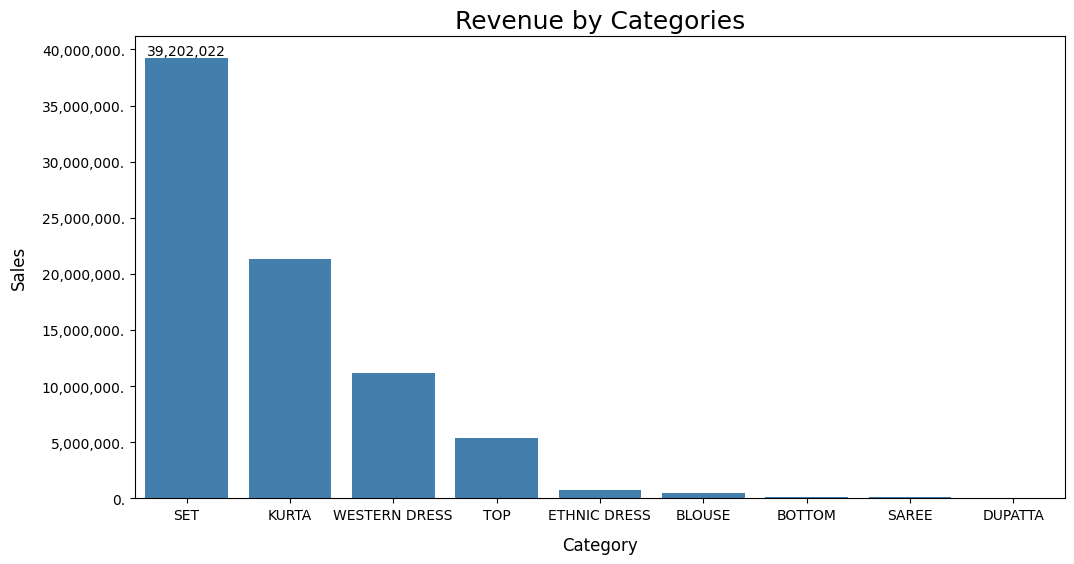

In [68]:
plt.figure(figsize = (12, 6))
ax_q1 = sns.barplot(y = 'Amount', x='Category', palette = ['#3182bd'], data = df_q1)
plt.title('Revenue by Categories', fontsize= _title_size)

formatter = ticker.StrMethodFormatter("{x:,.0f}.")
ax_q1.yaxis.set_major_formatter(formatter)
ax_q1.xaxis.labelpad = _axis_label_pad
ax_q1.yaxis.labelpad = _axis_label_pad

for i, bar in enumerate(ax_q1.containers[0].patches):
    ax_q1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
        '{:,.0f}'.format(bar.get_height()), ha='center', va='bottom')
plt.xlabel("Category", weight = _fweight, fontsize=_axis_label_size)
plt.ylabel("Sales", weight = _fweight, fontsize=_axis_label_size)
plt.savefig('img\\Revenue_by_categories.jpg', dpi=300)
plt.show()


# Answer Q2: Which are the 20 Best-Selling Products?

In [69]:
df_q2 = df.groupby(['Category', 'ASIN'])[['Qty','Amount']].sum()\
                                     .sort_values('Qty', ascending=False)\
                                     .head(20)\
                                     .reset_index()
df_q2

,Category,ASIN,Qty,Amount
0,WESTERN DRESS,B09SDXFFQ1,661,524581.77
1,WESTERN DRESS,B09SDY8DCT,561,454290.16
2,WESTERN DRESS,B09SDYQ3WG,503,407302.57
3,KURTA,B081WSCKPQ,485,194645.29
4,SET,B08XNJG8B1,467,526536.20
5,SET,B08XNJ19QH,421,479937.14
6,WESTERN DRESS,B09SDXRYBG,415,332155.24
7,KURTA,B081WX4G4Q,399,169808.87
8,WESTERN DRESS,B09SDY9SQ6,386,303616.70
9,SET,B08XQBF1G4,373,284058.96


/tmp/ipykernel_4633/2508318903.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_q2 = sns.barplot(y = 'Qty', x='ASIN', palette = col_list, data = df_q2)


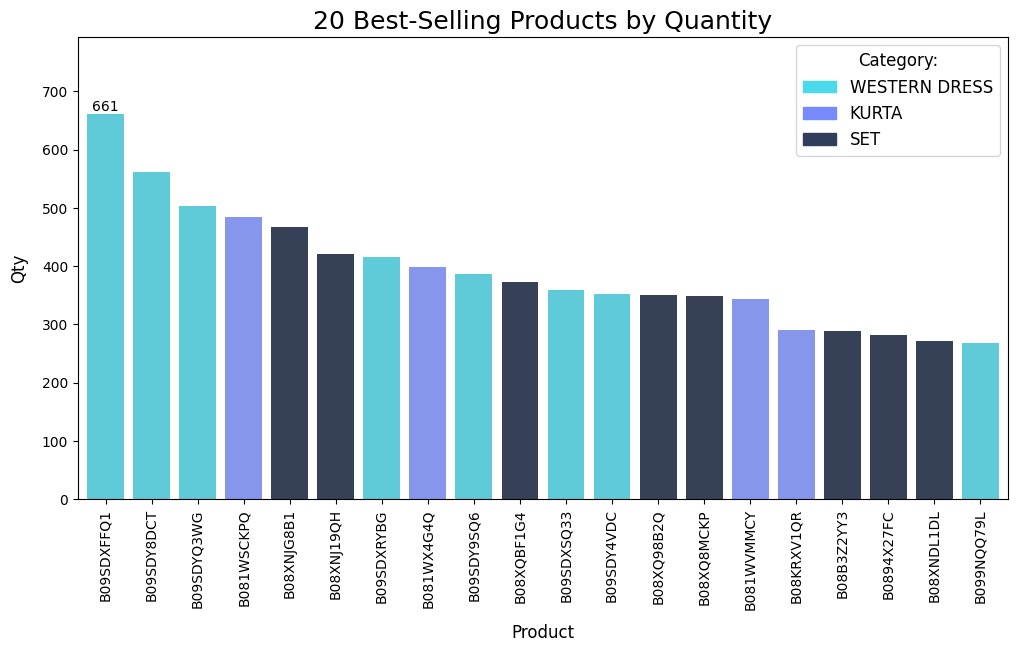

In [70]:
colors_dict = {'WESTERN DRESS': '#4BD9EC', 'KURTA': '#758BFD', 'SET': '#313E5B'}
col_list = [colors_dict.get(cat) for cat in df_q2['Category']]

plt.figure(figsize = (12, 6))
ax_q2 = sns.barplot(y = 'Qty', x='ASIN', palette = col_list, data = df_q2)
plt.title('20 Best-Selling Products by Quantity', fontsize=_title_size)

formatter = ticker.StrMethodFormatter("{x:,.0f}")
ax_q2.yaxis.set_major_formatter(formatter)
ax_q2.xaxis.labelpad = _axis_label_pad
ax_q2.yaxis.labelpad = _axis_label_pad
ax_q2.margins(0.01, 0.2)

for i, bar in enumerate(ax_q2.containers[0].patches):
    ax_q2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
        '{:,.0f}'.format(bar.get_height()), ha='center', va='bottom')
plt.xticks(rotation=90, ha='center')
plt.xlabel("Product", weight = _fweight, fontsize= _axis_label_size)
plt.ylabel("Qty", weight = _fweight, fontsize= _axis_label_size)

legend_entries = []
for elem in df_q2['Category'].unique():
    legend_entries.append(mpatches.Patch(color=colors_dict.get(elem), label=elem))
plt.legend(handles=legend_entries, title='Category:', title_fontsize= _legend_title_size, fontsize=_legend_content_size)
plt.savefig('img\\20_Best_Selling_Products_by_Quantity.jpg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

# Answer to Q3: Which are the 20 Best-Selling Products by Revenue?

In [71]:
df_q3 = df.groupby(['Category', 'ASIN'])[['Amount', 'Qty']].sum()\
                                     .sort_values('Amount', ascending=False)\
                                     .head(20)\
                                     .reset_index()
df_q3

,Category,ASIN,Amount,Qty
0,SET,B08XNJG8B1,526536.20,467
1,WESTERN DRESS,B09SDXFFQ1,524581.77,661
2,SET,B08XNJ19QH,479937.14,421
3,WESTERN DRESS,B09SDY8DCT,454290.16,561
4,WESTERN DRESS,B09SDYQ3WG,407302.57,503
5,WESTERN DRESS,B09SDXRYBG,332155.24,415
6,SET,B08XNDL1DL,305616.95,272
7,WESTERN DRESS,B09SDY9SQ6,303616.70,386
8,SET,B08XQBF1G4,284058.96,373
9,WESTERN DRESS,B09SDY4VDC,276375.80,353


/tmp/ipykernel_4633/2889143372.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_q3 = sns.barplot(y = 'Amount', x='ASIN', palette = col_list, data = df_q3)


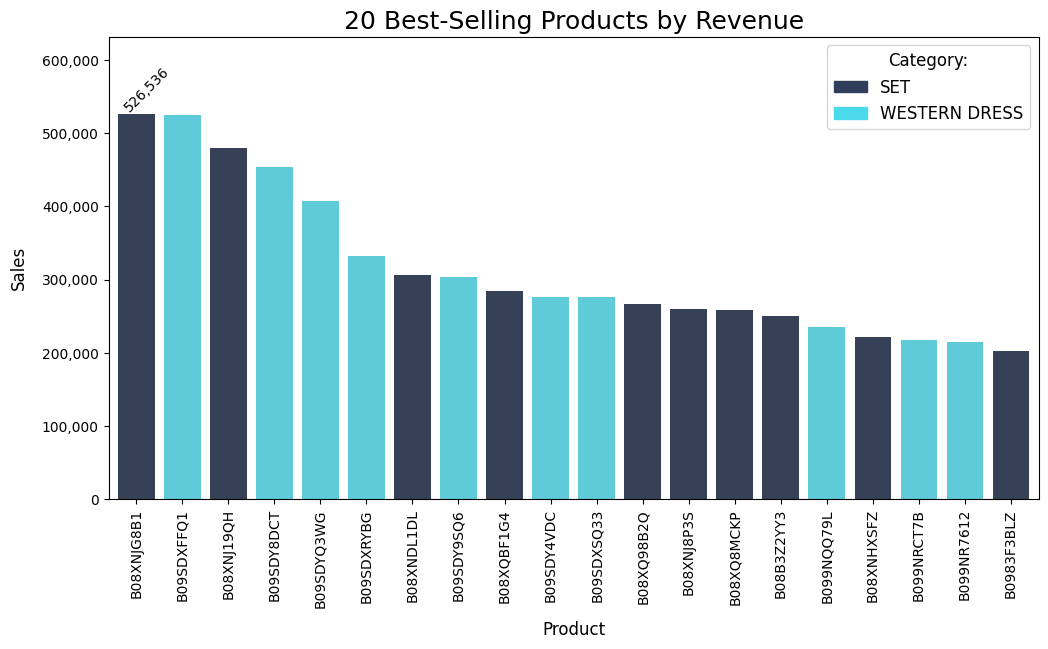

In [72]:
colors_dict = {'WESTERN DRESS': '#4BD9EC', 'KURTA': '#758BFD', 'SET': '#313E5B'}
col_list = [colors_dict.get(cat) for cat in df_q3['Category']]

plt.figure(figsize = (12, 6))
ax_q3 = sns.barplot(y = 'Amount', x='ASIN', palette = col_list, data = df_q3)
plt.title('20 Best-Selling Products by Revenue', fontsize=_title_size)

formatter = ticker.StrMethodFormatter("{x:,.0f}")
ax_q3.yaxis.set_major_formatter(formatter)
ax_q3.xaxis.labelpad = _axis_label_pad
ax_q3.yaxis.labelpad = _axis_label_pad

for i, bar in enumerate(ax_q3.containers[0].patches):
    ax_q3.text(bar.get_x() + bar.get_width()*0.8, bar.get_height(),
        '{:,.0f}'.format(bar.get_height()), ha='center', va='bottom', rotation=45)

plt.xticks(rotation=90, ha='center')
plt.xlabel("Product", weight = _fweight, fontsize= _axis_label_size)
plt.ylabel("Sales", weight = _fweight, fontsize= _axis_label_size)

legend_entries = []
for elem in df_q3['Category'].unique():
    legend_entries.append(mpatches.Patch(color=colors_dict.get(elem), label=elem))
plt.legend(handles=legend_entries, title='Category:', title_fontsize= _legend_title_size, fontsize=_legend_content_size)
ax_q3.margins(0.01, 0.2)
plt.savefig('img\\20_Best_Selling_Products_by_Revenue.jpg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

# Answer Q4: Which are the 20 cities that made the most orders?

In [73]:
df_q4 = df.groupby(['ship_state','ship_city'])[['Order_ID']].count()\
                                    .sort_values('Order_ID', ascending=False)\
                                    .head(20)\
                                    .reset_index()
df_q4

,ship_state,ship_city,Order_ID
0,KARNATAKA,BANGALORE,13342
1,TELANGANA,HYDERABAD,9092
2,MAHARASHTRA,MUMBAI,7122
3,DELHI,NEW DELHI,6753
4,TAMIL NADU,CHENNAI,6284
5,MAHARASHTRA,PUNE,4616
6,WEST BENGAL,KOLKATA,2844
7,HARYANA,GURUGRAM,1954
8,MAHARASHTRA,THANE,1877
9,UTTAR PRADESH,LUCKNOW,1627


/tmp/ipykernel_4633/845181310.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_q4 = sns.barplot(y = 'Order_ID', x='ship_city', palette = col_list, data = df_q4)


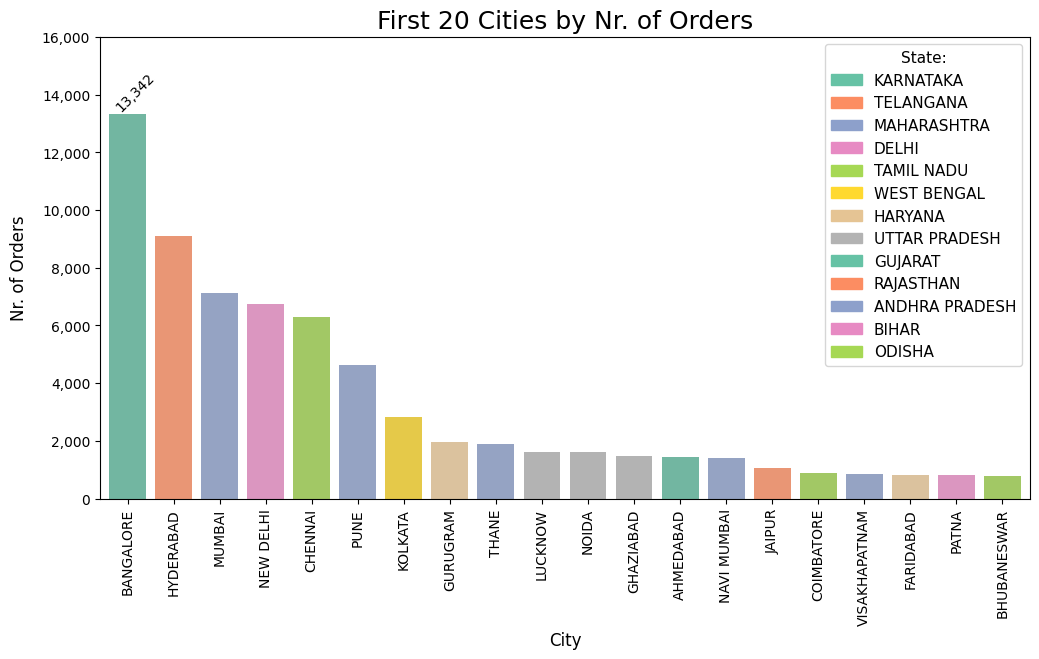

In [74]:
plt.figure(figsize = (12, 6))

plt.title('First 20 Cities by Nr. of Orders', fontsize=_title_size)

palette_colors = sns.color_palette('Set2',len(df_q4['ship_state'].unique()))
palette_dict = {state: color for state, color in zip(list(df_q4['ship_state'].unique()), palette_colors)}
col_list = [palette_dict.get(state) for state, city in zip(df_q4['ship_state'],df_q4['ship_city'])]

ax_q4 = sns.barplot(y = 'Order_ID', x='ship_city', palette = col_list, data = df_q4)

formatter = ticker.StrMethodFormatter("{x:,.0f}")
ax_q4.yaxis.set_major_formatter(formatter)
ax_q4.yaxis.labelpad = _axis_label_pad

for i, bar in enumerate(ax_q4.containers[0].patches):
    ax_q4.text(bar.get_x() + bar.get_width()*0.7, bar.get_height(),
        '{:,.0f}'.format(bar.get_height()), ha='center', va='bottom', rotation=45)
plt.xticks(rotation=90)
plt.xlabel("City", weight = _fweight, fontsize= _axis_label_size)
plt.ylabel("Nr. of Orders", weight = _fweight, fontsize= _axis_label_size)

legend_entries = []
for elem in df_q4['ship_state'].unique():
    legend_entries.append(mpatches.Patch(color=palette_dict.get(elem), label=elem))
plt.legend(handles=legend_entries, title='State:', title_fontsize= _legend_title_size-1, fontsize=_legend_content_size-1)

ax_q4.margins(0.01, 0.2)
plt.savefig('img\\First_20_Cities_by_Nr_of_Orders.jpg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

# Answer Q5: Which are the 20 cities that more income generate?

In [75]:
df_q5 = df.groupby(['ship_state','ship_city'])[['Amount','Qty']].sum()\
                                    .sort_values('Amount', ascending=False)\
                                     .head(20)\
                                    .reset_index()

/tmp/ipykernel_4633/847054564.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_q5 = sns.barplot(y = 'Amount', x='ship_city', palette = col_list, data = df_q5)


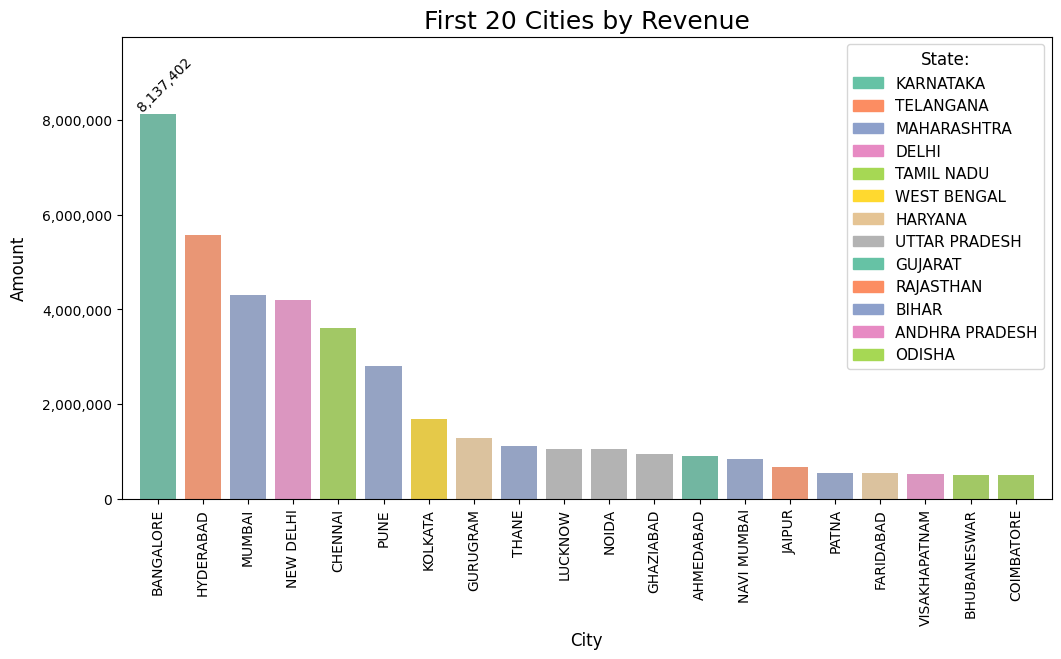

In [76]:
plt.figure(figsize = (12, 6))
plt.title('First 20 Cities by Revenue', fontsize=_title_size)

palette_colors = sns.color_palette('Set2',len(df_q5['ship_state'].unique()))
palette_dict = {state: color for state, color in zip(list(df_q5['ship_state'].unique()), palette_colors)}
col_list = [palette_dict.get(state) for state, city in zip(df_q5['ship_state'],df_q5['ship_city'])]

ax_q5 = sns.barplot(y = 'Amount', x='ship_city', palette = col_list, data = df_q5)

formatter = ticker.StrMethodFormatter("{x:,.0f}")
ax_q5.yaxis.set_major_formatter(formatter)

ax_q5.yaxis.labelpad = _axis_label_pad

for i, bar in enumerate(ax_q5.containers[0].patches):
    ax_q5.text(bar.get_x() + bar.get_width()*0.7, bar.get_height(),
        '{:,.0f}'.format(bar.get_height()), ha='center', va='bottom', rotation=45)
plt.xticks(rotation=90)
plt.xlabel("City", weight = _fweight, fontsize= _axis_label_size)
plt.ylabel("Amount", weight = _fweight, fontsize= _axis_label_size)

legend_entries = []
for elem in df_q5['ship_state'].unique():
    legend_entries.append(mpatches.Patch(color=palette_dict.get(elem), label=elem))
plt.legend(handles=legend_entries, title='State:', title_fontsize= _legend_title_size, fontsize=_legend_content_size-1)

ax_q5.margins(0.02, 0.2)
plt.savefig('img\\First_20_Cities_by_Revenue.jpg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

# Answer Q6: How many orders are fulfilled by Amazon and how many by the Merchant?

In [77]:
# How are the order volume and revenues distributed on the Fulfilment Method?
df_fulfilment_stats = pd.DataFrame(data= df.groupby(['Fulfilment'])['Order_ID'].count())
df_fulfilment_stats = df_fulfilment_stats.rename(columns={'Order_ID': 'Nr. of Orders'})
df_fulfilment_stats['% of Orders'] = [ x / (df_fulfilment_stats['Nr. of Orders'].sum()) for x in df_fulfilment_stats['Nr. of Orders'] ]
df_fulfilment_stats['Tot. Sales'] = df.groupby(['Fulfilment'])[['Amount']].sum()
df_fulfilment_stats['% of Tot. Sales'] = [ x / (df_fulfilment_stats['Tot. Sales'].sum()) for x in df_fulfilment_stats['Tot. Sales'] ]
df_fulfilment_stats

,Nr. of Orders,% of Orders,Tot. Sales,% of Tot. Sales
Fulfilment,,,,
Amazon,89692,0.695454,54319516.0,0.691176
Merchant,39277,0.304546,24270527.3,0.308824


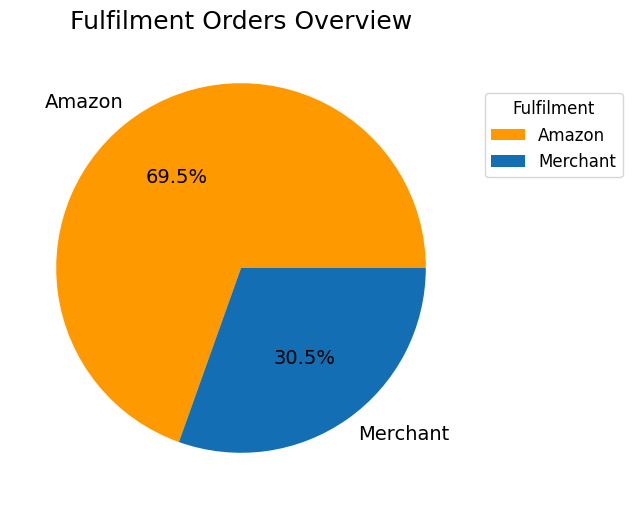

In [78]:
plt.figure(figsize = (8, 6))
fig_x2 = df['Fulfilment'].value_counts().plot.pie(autopct="%1.1f%%", colors = ('#FF9900','#146EB4'),
                                                  textprops={'fontsize': 14})
fig_x2.set(ylabel=None)
plt.legend(title = 'Fulfilment', title_fontsize= _legend_title_size, fontsize=_legend_content_size, bbox_to_anchor=(1,0.8),
                          bbox_transform=plt.gcf().transFigure)
plt.title('Fulfilment Orders Overview', fontsize= _title_size);
plt.savefig('img\\Fulfilment_Orders_Overview.jpg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [79]:
df_shipment_stats = df.query("Courier_Status != 'Unknown'").groupby(['Courier_Status','Fulfilment'])[['Amount','Qty']].sum()\
                                    .sort_values('Amount', ascending=False)\
                                    .reset_index()

In [80]:
df_shipment_stats

,Courier_Status,Fulfilment,Amount,Qty
0,Shipped,Amazon,50329299.0,77858
1,Shipped,Merchant,20726730.0,32035
2,Unshipped,Amazon,3990217.0,6226
3,Unshipped,Merchant,353625.0,527
4,Cancelled,Amazon,0.0,0


In [81]:
df_shipment_stats['Nr. of Orders'] = df.groupby(['Courier_Status','Fulfilment'])[['Order_ID']].count()\
                                    .sort_values('Order_ID', ascending=False)\
                                    .reset_index()['Order_ID']

In [82]:
df_shipment_stats

,Courier_Status,Fulfilment,Amount,Qty,Nr. of Orders
0,Shipped,Amazon,50329299.0,77858,77603
1,Shipped,Merchant,20726730.0,32035,31881
2,Unshipped,Amazon,3990217.0,6226,6872
3,Unshipped,Merchant,353625.0,527,6157
4,Cancelled,Amazon,0.0,0,5932


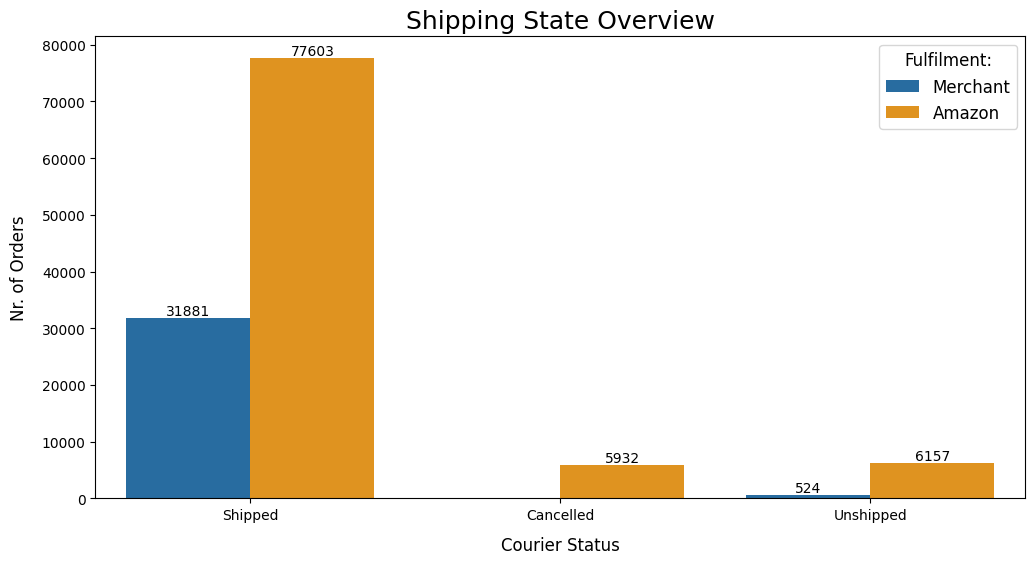

In [83]:
plt.figure(figsize = (12, 6))

ax6 = sns.countplot(x = 'Courier_Status', hue = 'Fulfilment', palette = ['#146EB4','#FF9900'], data = df.query("Courier_Status != 'Unknown'"));
plt.title('Shipping State Overview', fontsize=_title_size);
ax6.xaxis.labelpad = _axis_label_pad
ax6.yaxis.labelpad = _axis_label_pad

for i in ax6.containers:
    ax6.bar_label(i,)
plt.xlabel("Courier Status", weight = _fweight, fontsize= _axis_label_size)
plt.ylabel("Nr. of Orders", weight = _fweight, fontsize= _axis_label_size)
plt.legend(title='Fulfilment:', title_fontsize= _legend_title_size, fontsize=_legend_content_size)
plt.savefig('img\\Shipping_State_Overview.jpg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show;

In [84]:
df_q7 = df.groupby(['ship_city', 'Fulfilment'])[['Amount','Qty']].sum()\
                                    .sort_values('Amount', ascending=False)\
                                    .reset_index()

In [85]:
# 20 top cities
cities = []
i=0
while len(cities) < 20:
    if df_q7['ship_city'][i] not in cities:
        cities.append(df_q7['ship_city'][i])
    i+=1

# Amount by City, grouped by fulfilment
fulfil_stat_amz =[]
fulfil_stat_merc =[]
for city in cities:
    fulfil_stat_amz.append(df_q7.query("ship_city == '"+city+"' and Fulfilment == 'Amazon'").values[0][2])
    fulfil_stat_merc.append(df_q7.query("ship_city == '"+city+"' and Fulfilment == 'Merchant'").values[0][2])

# Arrays for bar-plot
fulfil_stat_amz = np.array(fulfil_stat_amz)
fulfil_stat_merc = np.array(fulfil_stat_merc)
total= np.add(fulfil_stat_amz,fulfil_stat_merc)

fulfil_dict = {
        'Amazon': (fulfil_stat_amz, np.array([amz/tot for tot, amz in zip(total, fulfil_stat_amz)])),
        'Merchant': (fulfil_stat_merc, np.array([merc/tot for tot, merc in zip(total, fulfil_stat_merc)]))
}

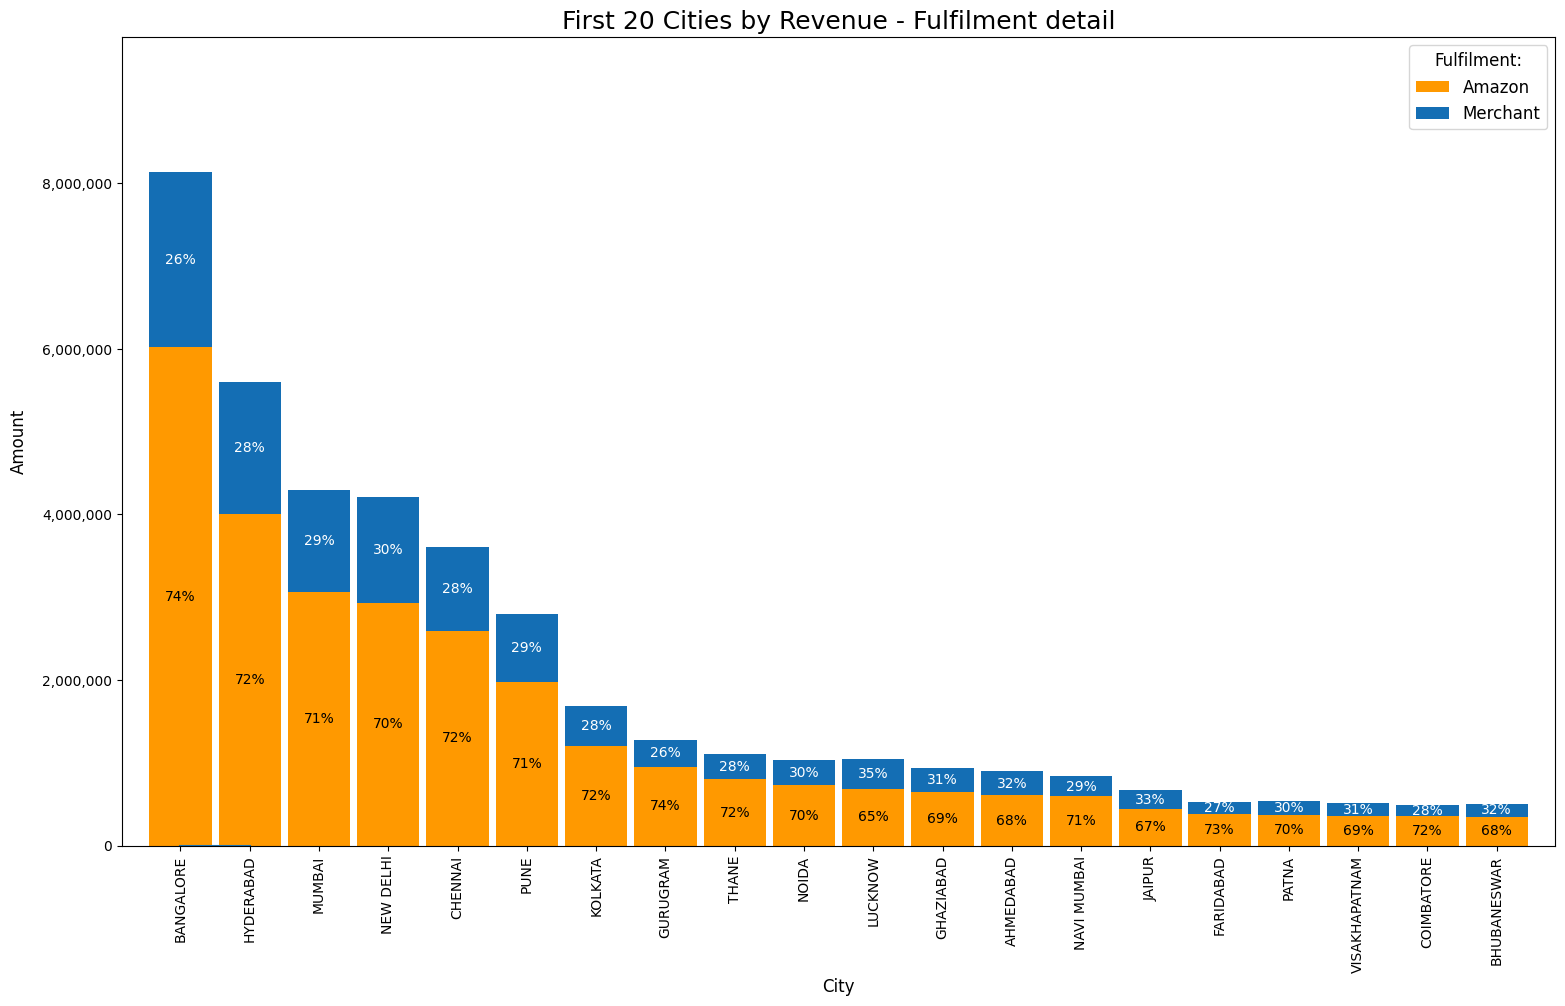

In [86]:
cities = tuple(cities)
ax_q7_width = 0.9
color_bars = ['#FF9900','#146EB4']
color_bar_labels= ['#000000','#FFFFFF']
fig_q7, ax_q7 = plt.subplots(1,1);
ax_q7.set_title('First 20 Cities by Revenue - Fulfilment detail', fontsize=_title_size)
fig_q7.set_size_inches(18.5, 10.5);

bottom = np.zeros(len(cities))
ax_q7.plot([1, 2])

for i, fulfil in enumerate(fulfil_dict.items()):
    p = ax_q7.bar(x= cities, height=fulfil[1][0], width=ax_q7_width, label=fulfil[0], bottom=bottom, color=color_bars[i])
    bottom += fulfil[1][0]
    ax_q7.bar_label(p, labels=[f"{x:.0%}" for x in fulfil[1][1]], label_type='center',color=color_bar_labels[i] )

formatter = ticker.StrMethodFormatter("{x:,.0f}")
ax_q7.yaxis.set_major_formatter(formatter)

ax_q7.yaxis.labelpad = _axis_label_pad


plt.xticks(rotation=90)
plt.xlabel("City", weight = _fweight, fontsize= _axis_label_size)
plt.ylabel("Amount", weight = _fweight, fontsize= _axis_label_size)

ax_q7.legend(title='Fulfilment:', title_fontsize= _legend_title_size, fontsize=_legend_content_size)
ax_q7.margins(0.02, 0.2)

plt.savefig('img\\First_20_Cities_by_Revenue_Fulfilment_hue.jpg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show();

The Fulfilment ratio between Amazon and Merchant is evenly distributed even when we consider the individual destination cities.

# FINAL CONCLUSIONS

In the course of the analysis:
* It was established that Western Dress, Kurta and Set are the categories which have sold most.
* It was verified that the 20 Best-Selling Products by quantity belongs to the categories Western Dress, Kurta and Set.  
* On the other hand, the 20 Best-Selling Products by revenue belongs only to the categories Western Dress and Set.  
* Also it was performed a fulfilment and shipping state overview, discovering an uniformly distributed fulfillment method even among the dectionation cities.

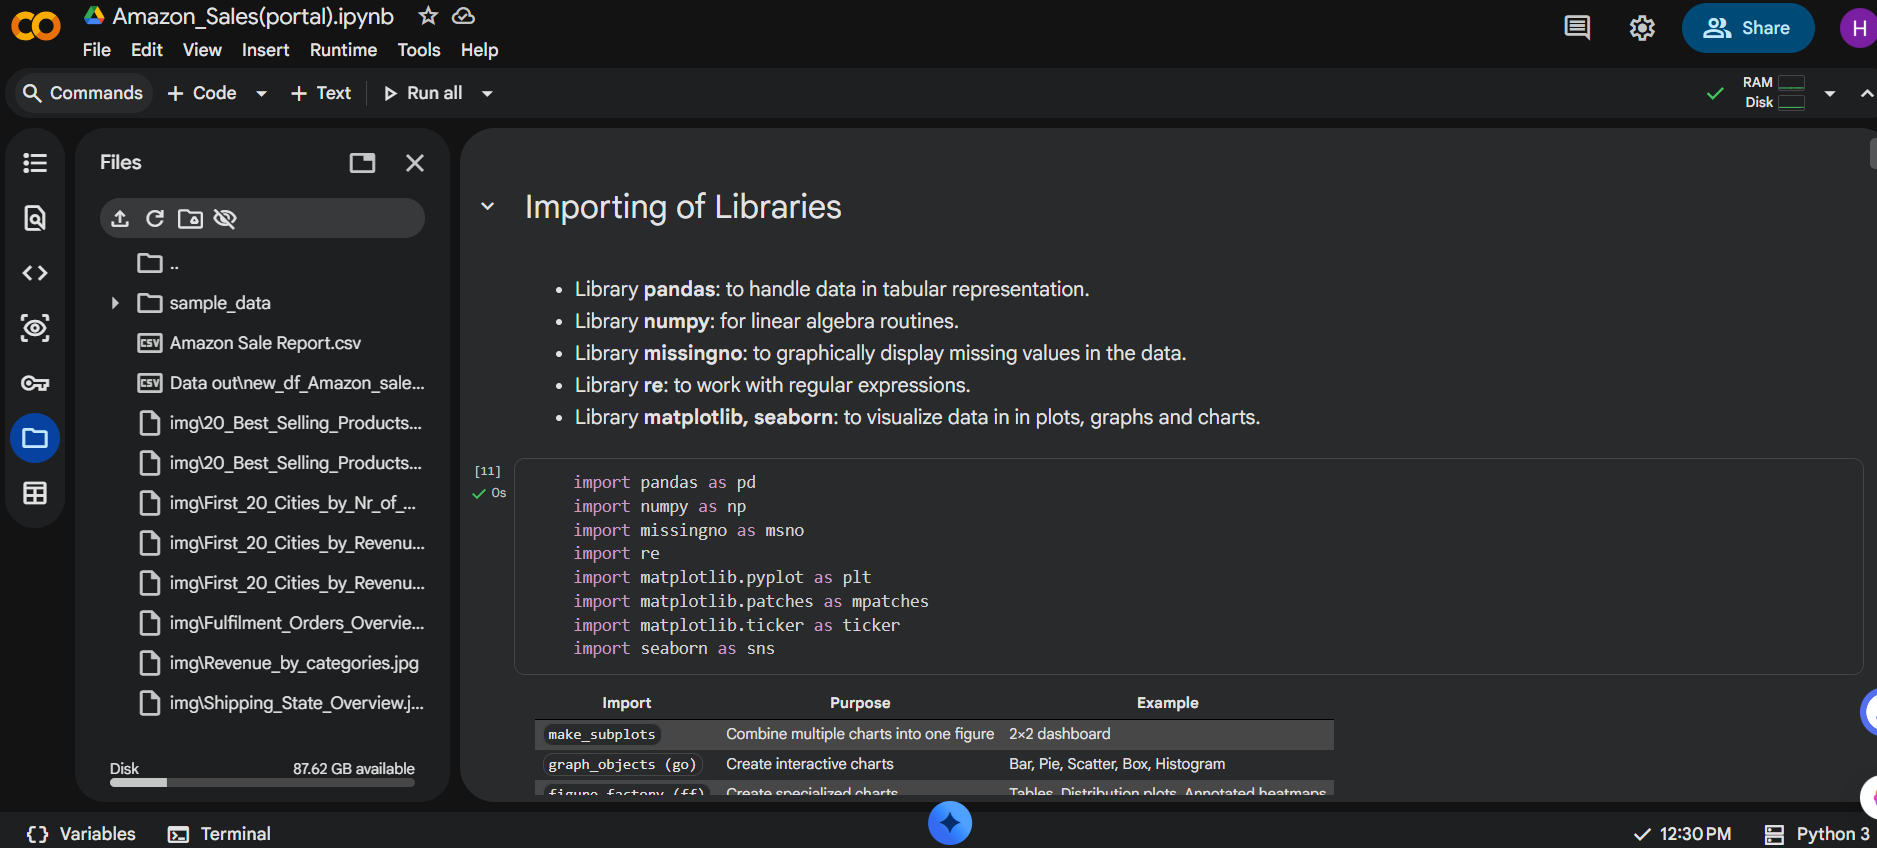